In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#Load dataset into DataFrame

In [2]:
df = pd.read_csv('employees.csv')

#Display first 10 records


In [3]:
print(df.head(10))

  First Name  Gender  Start Date Last Login Time  Salary  Bonus %  \
0    Douglas    Male    8/6/1993        12:42 PM   97308    6.945   
1     Thomas    Male   3/31/1996         6:53 AM   61933    4.170   
2      Maria  Female   4/23/1993        11:17 AM  130590   11.858   
3      Jerry    Male    3/4/2005         1:00 PM  138705    9.340   
4      Larry    Male   1/24/1998         4:47 PM  101004    1.389   
5     Dennis    Male   4/18/1987         1:35 AM  115163   10.125   
6       Ruby  Female   8/17/1987         4:20 PM   65476   10.012   
7        NaN  Female   7/20/2015        10:43 AM   45906   11.598   
8     Angela  Female  11/22/2005         6:29 AM   95570   18.523   
9    Frances  Female    8/8/2002         6:51 AM  139852    7.524   

  Senior Management                  Team  
0              True             Marketing  
1              True                   NaN  
2             False               Finance  
3              True               Finance  
4              True 

#Check dataset shape

In [4]:
print(df.shape)

(1000, 8)


#Print column names


In [5]:
print(df.columns)

Index(['First Name', 'Gender', 'Start Date', 'Last Login Time', 'Salary',
       'Bonus %', 'Senior Management', 'Team'],
      dtype='str')


#Check data types


In [6]:
print(df.dtypes)

First Name               str
Gender                   str
Start Date               str
Last Login Time          str
Salary                 int64
Bonus %              float64
Senior Management     object
Team                     str
dtype: object


#Count null values in each column


In [7]:
null_values = df.isnull().sum()
print(null_values)

First Name            67
Gender               145
Start Date             0
Last Login Time        0
Salary                 0
Bonus %                0
Senior Management     67
Team                  43
dtype: int64



#Handle missing values


In [8]:
df['Gender'] = df['Gender'].fillna ('Unknown')
df['Team'] = df['Team'].fillna('Unknown')

#Convert date column


In [9]:
df['Start Date'] = pd.to_datetime(df['Start Date'])

#Remove duplicates

In [10]:
df = df.drop_duplicates()

#Save cleaned data

In [11]:
df.to_csv(r"C:\Users\gs1-harishr\Python Projext\cleaned_data.csv", index=False)

#Show only First Name and Team


In [12]:
print(df[['First Name', 'Team']])

    First Name                  Team
0      Douglas             Marketing
1       Thomas               Unknown
2        Maria               Finance
3        Jerry               Finance
4        Larry       Client Services
..         ...                   ...
995      Henry          Distribution
996    Phillip               Finance
997    Russell               Product
998      Larry  Business Development
999     Albert                 Sales

[1000 rows x 2 columns]


#Count total employees


In [13]:
total_employees = len(df)
print("Total Employees count: ", total_employees)

Total Employees count:  1000


#Count unique teams


In [14]:
unique_teams = df['Team'].nunique()
print('Unique Teams: ', unique_teams)

Unique Teams:  11


#Sort employees by salary (ascending/descending)



In [15]:
Salay_ascending = df[['First Name', 'Salary']].sort_values('Salary')
print(Salay_ascending)

    First Name  Salary
576    Michael   35013
238      Kevin   35061
82      Steven   35095
63     Matthew   35203
650    Cynthia   35381
..         ...     ...
160      Kathy  149563
186        NaN  149654
828    Cynthia  149684
429       Rose  149903
644  Katherine  149908

[1000 rows x 2 columns]


In [16]:
salary_decending = df[['First Name' , 'Salary']].sort_values(by="Salary", ascending=False)
print(salary_decending)


    First Name  Salary
644  Katherine  149908
429       Rose  149903
828    Cynthia  149684
186        NaN  149654
160      Kathy  149563
..         ...     ...
650    Cynthia   35381
63     Matthew   35203
82      Steven   35095
238      Kevin   35061
576    Michael   35013

[1000 rows x 2 columns]


#Count employees in each team



In [17]:
df.groupby('Team')['Gender'].count()

Team
Business Development    101
Client Services         106
Distribution             90
Engineering              92
Finance                 102
Human Resources          91
Legal                    88
Marketing                98
Product                  95
Sales                    94
Unknown                  43
Name: Gender, dtype: int64

#Employees with salary > 100,000


In [18]:
df[df['Salary'] > 100000 ]

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
2,Maria,Female,1993-04-23,11:17 AM,130590,11.858,False,Finance
3,Jerry,Male,2005-03-04,1:00 PM,138705,9.340,True,Finance
4,Larry,Male,1998-01-24,4:47 PM,101004,1.389,True,Client Services
5,Dennis,Male,1987-04-18,1:35 AM,115163,10.125,False,Legal
9,Frances,Female,2002-08-08,6:51 AM,139852,7.524,True,Business Development
...,...,...,...,...,...,...,...,...
990,Robin,Female,1987-07-24,1:35 PM,100765,10.982,True,Client Services
991,Rose,Female,2002-08-25,5:12 AM,134505,11.051,True,Marketing
992,Anthony,Male,2011-10-16,8:35 AM,112769,11.625,True,Finance
995,Henry,Unknown,2014-11-23,6:09 AM,132483,16.655,False,Distribution


#Find employees in Senior Management


In [19]:
df[df['Senior Management'] == True]

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,1993-08-06,12:42 PM,97308,6.945,True,Marketing
1,Thomas,Male,1996-03-31,6:53 AM,61933,4.170,True,Unknown
3,Jerry,Male,2005-03-04,1:00 PM,138705,9.340,True,Finance
4,Larry,Male,1998-01-24,4:47 PM,101004,1.389,True,Client Services
6,Ruby,Female,1987-08-17,4:20 PM,65476,10.012,True,Product
...,...,...,...,...,...,...,...,...
991,Rose,Female,2002-08-25,5:12 AM,134505,11.051,True,Marketing
992,Anthony,Male,2011-10-16,8:35 AM,112769,11.625,True,Finance
993,Tina,Female,1997-05-15,3:53 PM,56450,19.040,True,Engineering
994,George,Male,2013-06-21,5:47 PM,98874,4.479,True,Marketing


#Creating new column with First name and Team

In [21]:
df['full_info'] = df['First Name'] + ' ' + df['Team']
print(df[['First Name' , 'Team', 'full_info']].head(10))

  First Name                  Team                     full_info
0    Douglas             Marketing             Douglas Marketing
1     Thomas               Unknown                Thomas Unknown
2      Maria               Finance                 Maria Finance
3      Jerry               Finance                 Jerry Finance
4      Larry       Client Services         Larry Client Services
5     Dennis                 Legal                  Dennis Legal
6       Ruby               Product                  Ruby Product
7        NaN               Finance                           NaN
8     Angela           Engineering            Angela Engineering
9    Frances  Business Development  Frances Business Development


#Average Salary per Team Rounded off

In [24]:
Average_salary = df.groupby('Team')['Salary'].mean().round()
print(Average_salary)

Team
Business Development    91866.0
Client Services         88224.0
Distribution            88500.0
Engineering             94269.0
Finance                 92219.0
Human Resources         90945.0
Legal                   89304.0
Marketing               90436.0
Product                 88666.0
Sales                   92173.0
Unknown                 90763.0
Name: Salary, dtype: float64


#Highest Salary in each team

In [25]:
Highest_Salary = df.groupby('Team')['Salary'].max()
print(Highest_Salary)

Team
Business Development    147417
Client Services         147183
Distribution            149105
Engineering             147362
Finance                 149908
Human Resources         149903
Legal                   148985
Marketing               149456
Product                 149684
Sales                   149654
Unknown                 148291
Name: Salary, dtype: int64


#Employees per gender

In [28]:
gender = df.groupby('Gender')['Gender'].count()
print(gender)

Gender
Female     431
Male       424
Unknown    145
Name: Gender, dtype: int64


#Employees joined after 2010

In [29]:
after_2010 = df[df['Start Date'] > '2010-12-31' ]
print(after_2010[['full_info', 'Start Date']])

                      full_info Start Date
7                           NaN 2015-07-20
15              Lillian Product 2016-06-05
22       Joshua Client Services 2012-03-08
23                          NaN 2012-06-14
25                          NaN 2012-10-08
..                          ...        ...
994            George Marketing 2013-06-21
995          Henry Distribution 2014-11-23
997             Russell Product 2013-05-20
998  Larry Business Development 2013-04-20
999                Albert Sales 2012-05-15

[152 rows x 2 columns]


#Salary Distribution

In [32]:
print(df["Salary"].describe().round())

count      1000.0
mean      90662.0
std       32924.0
min       35013.0
25%       62613.0
50%       90428.0
75%      118740.0
max      149908.0
Name: Salary, dtype: float64


#Employees with bonus > 15%

In [36]:
Higher_bonus = df[df['Bonus %'] > 15]
print(Higher_bonus[['First Name', 'Team']].head(10))

   First Name                  Team
8      Angela           Engineering
10     Louise               Unknown
12    Brandon       Human Resources
18      Diana       Client Services
22     Joshua       Client Services
25        NaN       Client Services
33       Jean  Business Development
34      Jerry       Client Services
35    Theresa                 Sales
42    Beverly                 Legal


#Teams with highest average salary

In [39]:
sort_average_salary = Average_salary.sort_values(ascending= False).head(5)
print(sort_average_salary)

Team
Engineering             94269.0
Finance                 92219.0
Sales                   92173.0
Business Development    91866.0
Human Resources         90945.0
Name: Salary, dtype: float64


#Employees who logged in after 6 PM

In [41]:
df.columns

Index(['First Name', 'Gender', 'Start Date', 'Last Login Time', 'Salary',
       'Bonus %', 'Senior Management', 'Team', 'full_info'],
      dtype='str')

In [46]:
df['Last Login Time'] = pd.to_datetime(df['Last Login Time'])
late_login = df[df['Last Login Time'].dt.hour >=18]
print(late_login[['full_info', 'Last Login Time']].head(10))

                      full_info     Last Login Time
13                   Gary Sales 2026-06-26 23:40:00
17                Shawn Product 2026-06-26 19:45:00
20                   Lois Legal 2026-06-26 19:18:00
24         John Client Services 2026-06-26 22:08:00
27                  Scott Legal 2026-06-26 18:58:00
28        Terry Client Services 2026-06-26 18:30:00
29               Benjamin Legal 2026-06-26 22:06:00
36  Rachel Business Development 2026-06-26 20:47:00
37        Linda Client Services 2026-06-26 20:49:00
42                Beverly Legal 2026-06-26 20:26:00


#Ranking of employees based on salary

In [49]:
df['Rank'] = df['Salary'].rank(ascending=False, method='dense').astype(int)
rank_sorted = df.sort_values(by='Rank', ascending=True)
print(rank_sorted[['full_info', 'Rank']].head(20))

                       full_info  Rank
644            Katherine Finance     1
429         Rose Human Resources     2
828              Cynthia Product     3
186                          NaN     4
160                Kathy Finance     5
740            Russell Marketing     6
793          Andrea Distribution     7
981                  James Legal     8
800             Clarence Product     9
844                  Maria Legal    10
765                Alice Finance    11
850              Charles Unknown    12
318                  Roy Finance    13
83                 Shawn Finance    14
851                Bobby Unknown    15
232      Marilyn Human Resources    16
471       Sharon Human Resources    17
721  Harold Business Development    18
541             Ruby Engineering    19
628                          NaN    20


In [51]:
df.to_csv(r"C:\Users\gs1-harishr\Python Projext\employees.csv", index=False)

#Top Teams by Employee Count

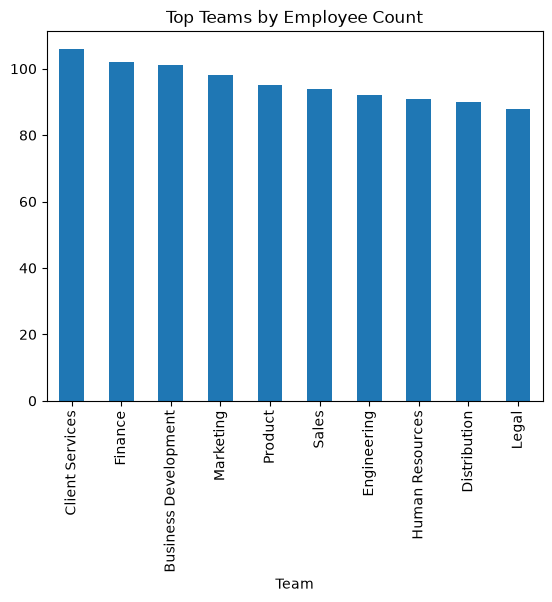

In [50]:
df["Team"].value_counts().head(10).plot(kind="bar")
plt.title("Top Teams by Employee Count")
plt.show()